In [9]:
import NeuralImplicit as NI
import network_defs as net_defs
import torch
import importlib
import matplotlib.pyplot as plt
importlib.reload(net_defs)
importlib.reload(NI)
#set torch default dtype to float64
torch.set_default_dtype(torch.float64)


In [10]:
architecture = [2, 256,256,256,256,3]
model = net_defs.Siren_jo(architecture=architecture,outermost_linear=True, first_omega_0=15, hidden_omega_0=30)
print(f'Number of parameters: {sum(p.numel() for p in model.parameters())}')
model.optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
model.lr_scheduler = torch.optim.lr_scheduler.StepLR(model.optimizer, step_size=300, gamma=0.8)


Number of parameters: 198915


In [11]:
NUM_EPOCHS = 10000
BATCH_SIZE = 1024
FUN_NUM = 2
NI.train_model_simple(model, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, fun_num=FUN_NUM, 
                      boundary_error_coeff=0.0,
                      eikon_coeff=0.0,
                      hotspot_coeff=0.0,
                      use_scheduler=True, 
                      epsilon=1e-1,
                      device=torch.device('cpu'))


Epoch [0], Loss: 0.3235548550401964, Acc: 0.3235548550401964
Epoch [999], Loss: 0.00202000134204932, Acc: 0.00202000134204932
Epoch [1999], Loss: 0.00121143761279781, Acc: 0.00121143761279781
Epoch [2999], Loss: 0.0009777821035702623, Acc: 0.0009777821035702623
Epoch [3999], Loss: 0.0006765847707392589, Acc: 0.0006765847707392589
Epoch [4999], Loss: 0.0006225965711237186, Acc: 0.0006225965711237186
Epoch [5999], Loss: 0.0006018941870024464, Acc: 0.0006018941870024464
Epoch [6999], Loss: 0.0007548999920090547, Acc: 0.0007548999920090547
Epoch [7999], Loss: 0.0005264531088748457, Acc: 0.0005264531088748457
Epoch [8999], Loss: 0.0007272543444257522, Acc: 0.0007272543444257522
Epoch [9999], Loss: 0.0005720647210799595, Acc: 0.0005720647210799595


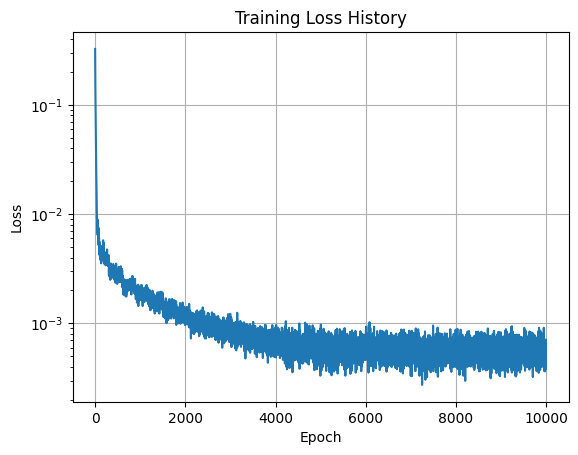

In [12]:
plt.plot(model.loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.grid()
plt.show()

In [13]:
importlib.reload(NI)
NI.evaluate_model_random_points(model, function_case=2,N=10000)

Model evaluation on N=10000 random points (function_case=2):
  Value errors: mean_abs=9.087946e-05, max_abs=9.318411e-03, L2=3.664429e-04
  Grad-norm errors (|grad|-1): mean_abs=7.608519e-03, max_abs=8.831838e-01, L2=4.141896e-02
  Hessian-diagonal errors (target 0): mean_abs=1.159393e+00, max_abs=5.434120e+01, L2=3.671525e+00


{'N': 10000,
 'function_case': 2,
 'global': {'value_mean_abs_error': 9.087946338588932e-05,
  'value_max_abs_error': 0.009318411356414757,
  'value_l2_error': 0.0003664429413904572,
  'grad_norm_mean_abs_error': 0.007608518745814026,
  'grad_norm_max_abs_error': 0.8831837857069257,
  'grad_norm_l2_error': 0.04141896494244664,
  'hessian_diag_mean_abs_error': 1.1593934332242515,
  'hessian_diag_max_abs_error': 54.34119765257336,
  'hessian_diag_l2_error': 3.6715248277895944}}

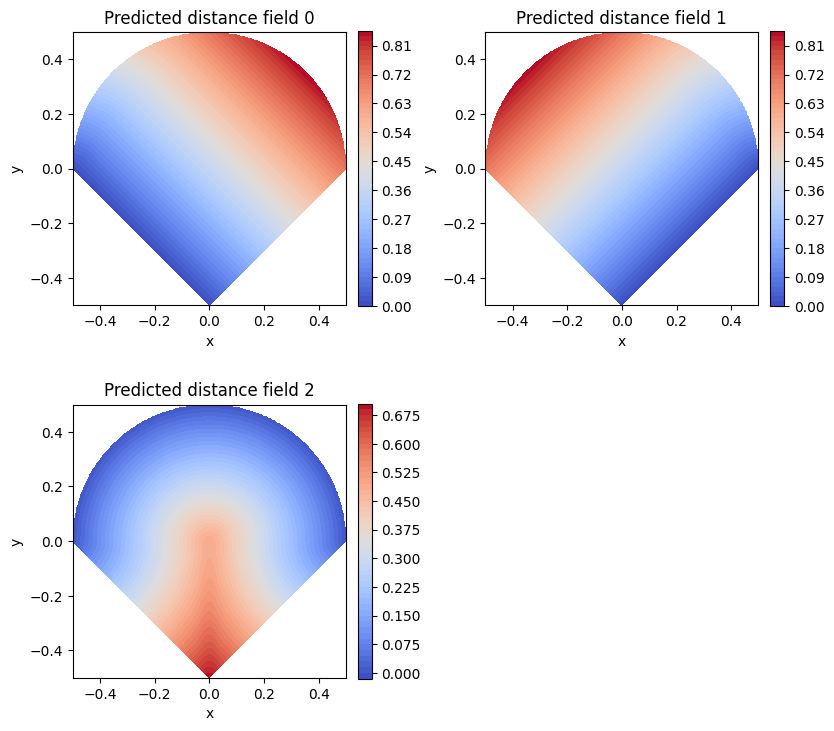

In [15]:
_=NI.plot_nn_distance_fields(model,extent=[-0.5,0.5,-0.5,0.5],fun_num=2,mask_outside_domain=True, device=torch.device('cpu'))

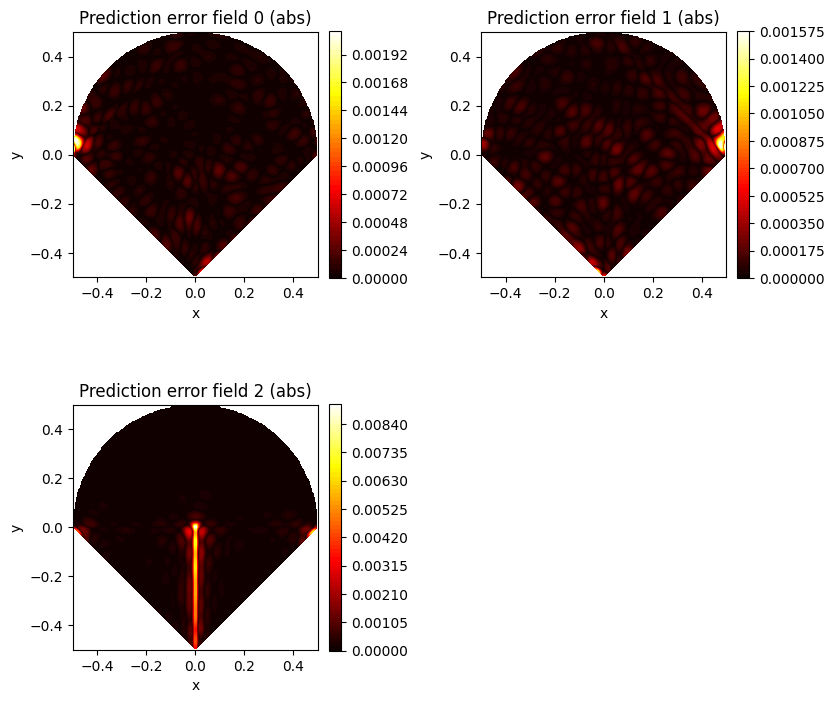

In [16]:
_=NI.plot_nn_prediction_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

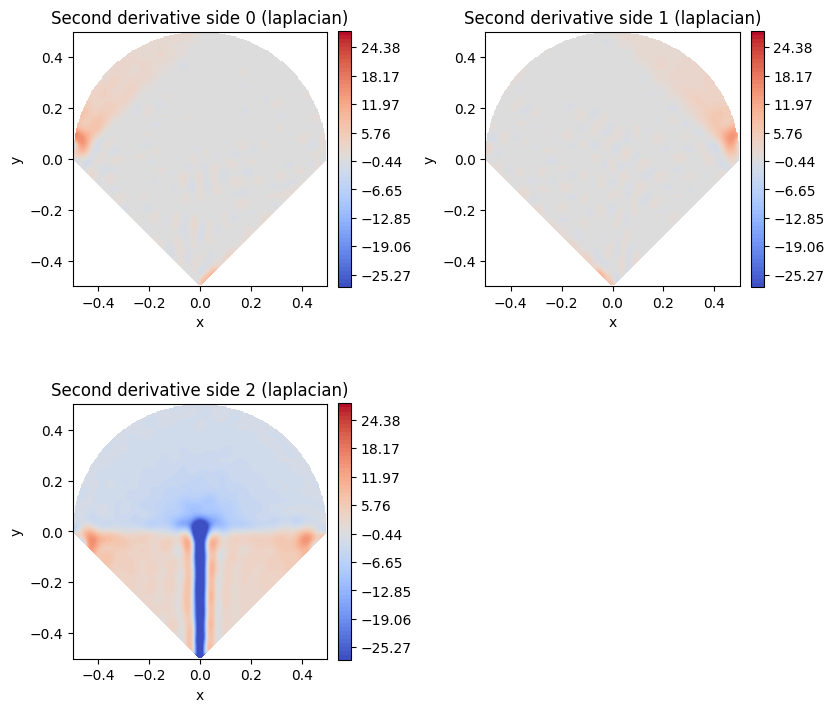

In [17]:
_=NI.plot_local_per_side_second_derivative(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

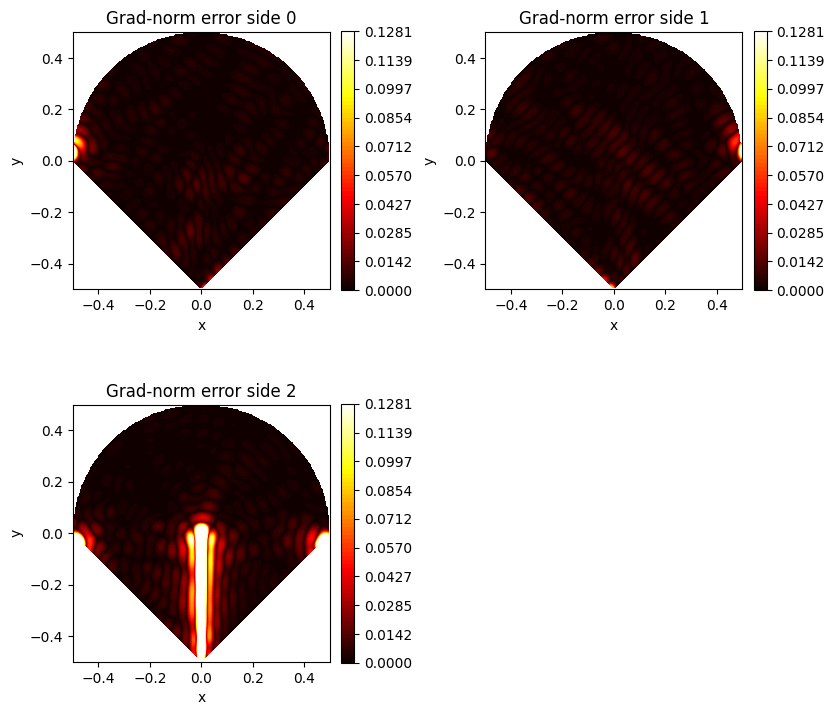

In [18]:
_=NI.plot_local_per_side_gradient_error(model, extent=[-0.5,0.5,-0.5,0.5], fun_num=2,device=torch.device('cpu'))

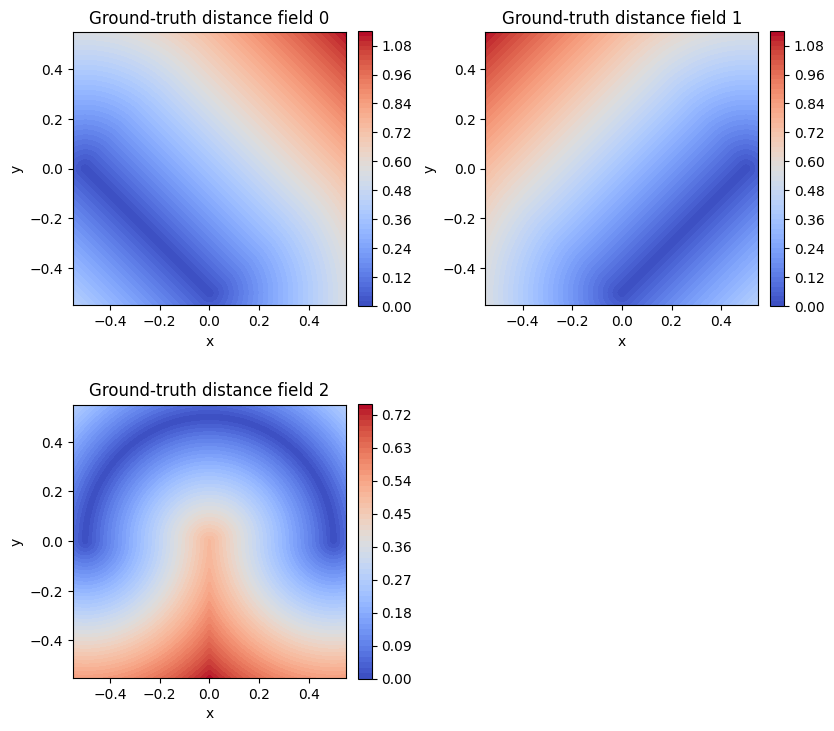

(<Figure size 840x760 with 7 Axes>,
 array([[<Axes: title={'center': 'Ground-truth distance field 0'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Ground-truth distance field 1'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Ground-truth distance field 2'}, xlabel='x', ylabel='y'>,
         <Axes: >]], dtype=object),
 array([[0.42426407, 0.55226805, 0.55226805],
        [0.42166267, 0.55194714, 0.54860433],
        [0.41906128, 0.55165057, 0.54494082],
        ...,
        [1.12616806, 0.54494082, 0.27263218],
        [1.12876945, 0.54860433, 0.27522043],
        [1.13137085, 0.55226805, 0.27781746]]))

In [13]:
importlib.reload(NI)
# Ground-truth visualization for testcase 2 (2 straight sides + 1 curved arc)
case2_params = {
    "radius": 0.5,
    "center": (0.0, 0.0),
    "apex": (0.0, -0.5),
}

NI.plot_ground_truth_distance_fields(
    resolution=300,
    extent=(-0.55, 0.55, -0.55, 0.55),
    fun_num=2,
    data_gen_params=case2_params,
    mask_outside_domain=False,
    device=torch.device('cpu'),
)

In [ ]:
import multi_SDF as SDF
